# Group Assignment 1
## Variant: Regional Manager


#### Prepared by:
- Viktoriia Lushpak
- Oleksandra Shergina
- Maksym Hobela
- Yanishevskyi Volodymyr

## Setup

In [0]:
from pyspark.sql.types import *
from pyspark.sql import functions as F

dbutils.widgets.text("catalog", "workspace", "Catalog")
catalog = dbutils.widgets.get("catalog")
BRONZE = "bronze"
SILVER = "silver"
GOLD = "gold"
for layer in ["bronze", "silver", "gold"]:
    spark.sql(f"CREATE SCHEMA IF NOT EXISTS {catalog}.{layer}")
    print(f"Created {catalog}.{layer}")

Created workspace.bronze
Created workspace.silver
Created workspace.gold


## Bronze Layer

In the bronze layer, we will load all the data as-is. We
ll start by reading the sample files into memory:

In [0]:
SOURCE = "samples.tpch"

TABLES = ["region", "nation", "supplier", "customer", "part", "partsupp", "orders", "lineitem"]

raw_data = {}
for t in TABLES:
    df = spark.table(f"{SOURCE}.{t}")
    raw_data[t] = df
    print(f"  Loaded {t} : {df.count():,} rows, {len(df.columns)} columns")

print(f"\nAll {len(TABLES)} TPC-H tables loaded from {SOURCE}")
print("Available in dict `raw_data`, e.g. raw_data['region'].show()")

  Loaded region : 5 rows, 3 columns
  Loaded nation : 25 rows, 4 columns
  Loaded supplier : 50,000 rows, 7 columns
  Loaded customer : 750,000 rows, 8 columns
  Loaded part : 1,000,000 rows, 9 columns
  Loaded partsupp : 4,000,000 rows, 5 columns
  Loaded orders : 7,500,000 rows, 9 columns
  Loaded lineitem : 29,999,795 rows, 16 columns

All 8 TPC-H tables loaded from samples.tpch
Available in dict `raw_data`, e.g. raw_data['region'].show()


Let's check the contents of the customers table to see if everything loaded correctly:

In [0]:
raw_data['customer'].show()

+---------+------------------+--------------------+-----------+---------------+---------+------------+--------------------+
|c_custkey|            c_name|           c_address|c_nationkey|        c_phone|c_acctbal|c_mktsegment|           c_comment|
+---------+------------------+--------------------+-----------+---------------+---------+------------+--------------------+
|   412445|Customer#000412445|0QAB3OjYnbP6mA0B,kgf|         21|31-421-403-4333|  5358.33|    BUILDING|arefully blithely...|
|   412446|Customer#000412446|5u8MSbyiC7J,7PuY4...|         20|30-487-949-7942|  9441.59|   MACHINERY|sleep according t...|
|   412447|Customer#000412447|HC4ZT62gKPgrjr ce...|          7|17-797-466-6308|  7868.75|  AUTOMOBILE|aggle blithely am...|
|   412448|Customer#000412448|         hJok1MMrDgH|          6|16-541-510-4964|  6060.98|   MACHINERY|ly silent request...|
|   412449|Customer#000412449|zAt1nZNG01gOhIqgy...|         14|24-710-983-5536|  4973.84|   HOUSEHOLD|refully final the...|
|   4124

Seems like the the data is correct. Saving all of the tables into `bronze`:

In [0]:
for t in TABLES:
    df = (
        raw_data[t]
        .withColumn("_ingested_at", F.current_timestamp())
        .withColumn("_source", F.lit(f"{SOURCE}.{t}"))
    )
    df.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable(f"bronze.{t}")
    print(f"Successfully saved bronze.{t}")

Successfully saved bronze.region
Successfully saved bronze.nation
Successfully saved bronze.supplier
Successfully saved bronze.customer
Successfully saved bronze.part
Successfully saved bronze.partsupp
Successfully saved bronze.orders
Successfully saved bronze.lineitem


Checking if all the data had been saved successfully - the number of rows should be equal:

In [0]:
print("Table        | raw_data  | bronze   | match?")
print("-" * 45)
all_match = True
for t in TABLES:
    raw_count = raw_data[t].count()
    bronze_count = spark.table(f"bronze.{t}").count()
    match = raw_count == bronze_count
    all_match = all_match and match
    print(f"{t:12s} | {raw_count:>9,} | {bronze_count:>8,} | {'✓' if match else '✗'}")

print("-" * 45)
print("All tables match!" if all_match else "MISMATCH detected — check above.")

Table        | raw_data  | bronze   | match?
---------------------------------------------
region       |         5 |        5 | ✓
nation       |        25 |       25 | ✓
supplier     |    50,000 |   50,000 | ✓
customer     |   750,000 |  750,000 | ✓
part         | 1,000,000 | 1,000,000 | ✓
partsupp     | 4,000,000 | 4,000,000 | ✓
orders       | 7,500,000 | 7,500,000 | ✓
lineitem     | 29,999,795 | 29,999,795 | ✓
---------------------------------------------
All tables match!


## Silver Layer

The main task of the Silver Layer is to transform the Bronze data into a clean, trustworthy, 3NF relational model. This includes ensuring clear column naming and data types, preserving the relational structure, as well as applying meaningful data-quality rules.

Since TPC-H is already a structured relational dataset designed according to a normalized schema, the Silver layer will verify existing relationships and normalization, identify appropriate quality constraints and create the Silver tables.

In [0]:
%sql
CREATE SCHEMA IF NOT EXISTS quarantine;

-- 1. REGION
CREATE TABLE IF NOT EXISTS silver.region (
    region_key BIGINT NOT NULL,
    name STRING NOT NULL,
    comment STRING,
    processed_at TIMESTAMP,
    dq_status STRING,
    CONSTRAINT pk_region PRIMARY KEY (region_key)
);

-- 2. NATION
CREATE TABLE IF NOT EXISTS silver.nation (
    nation_key BIGINT NOT NULL,
    name STRING NOT NULL,
    region_key BIGINT NOT NULL,
    comment STRING,
    processed_at TIMESTAMP,
    dq_status STRING,
    CONSTRAINT pk_nation PRIMARY KEY (nation_key),
    CONSTRAINT fk_nation_region FOREIGN KEY (region_key) REFERENCES silver.region(region_key)
);

-- 3. SUPPLIER
CREATE TABLE IF NOT EXISTS silver.supplier (
    supplier_key BIGINT NOT NULL,
    name STRING NOT NULL,
    address STRING,
    nation_key BIGINT NOT NULL,
    phone STRING,
    acctbal DECIMAL(18,2),
    comment STRING,
    processed_at TIMESTAMP,
    dq_status STRING,
    CONSTRAINT pk_supplier PRIMARY KEY (supplier_key),
    CONSTRAINT fk_supplier_nation FOREIGN KEY (nation_key) REFERENCES silver.nation(nation_key)
);

-- 4. CUSTOMER
CREATE TABLE IF NOT EXISTS silver.customer (
    customer_key BIGINT NOT NULL,
    name STRING NOT NULL,
    address STRING,
    nation_key BIGINT NOT NULL,
    phone STRING,
    acctbal DECIMAL(18,2),
    market_segment STRING,
    comment STRING,
    processed_at TIMESTAMP,
    dq_status STRING,
    CONSTRAINT pk_customer PRIMARY KEY (customer_key),
    CONSTRAINT fk_customer_nation FOREIGN KEY (nation_key) REFERENCES silver.nation(nation_key)
);

-- 5. PART
CREATE TABLE IF NOT EXISTS silver.part (
    part_key BIGINT NOT NULL,
    name STRING NOT NULL,
    manufacturer STRING,
    brand STRING,
    type STRING,
    size INT,
    container STRING,
    retail_price DECIMAL(18,2),
    comment STRING,
    processed_at TIMESTAMP,
    dq_status STRING,
    CONSTRAINT pk_part PRIMARY KEY (part_key)
);

-- 6. PARTSUPP
CREATE TABLE IF NOT EXISTS silver.partsupp (
    part_key BIGINT NOT NULL,
    supplier_key BIGINT NOT NULL,
    availqty INT,
    supply_cost DECIMAL(18,2),
    comment STRING,
    processed_at TIMESTAMP,
    dq_status STRING,
    CONSTRAINT pk_partsupp PRIMARY KEY (part_key, supplier_key),
    CONSTRAINT fk_partsupp_part FOREIGN KEY (part_key) REFERENCES silver.part(part_key),
    CONSTRAINT fk_partsupp_supplier FOREIGN KEY (supplier_key) REFERENCES silver.supplier(supplier_key)
);

-- 7. ORDERS
CREATE TABLE IF NOT EXISTS silver.orders (
    order_key BIGINT NOT NULL,
    customer_key BIGINT NOT NULL,
    order_status STRING,
    total_price DECIMAL(18,2),
    order_date DATE,
    order_priority STRING,
    clerk STRING,
    ship_priority INT,
    comment STRING,
    processed_at TIMESTAMP,
    dq_status STRING,
    CONSTRAINT pk_orders PRIMARY KEY (order_key),
    CONSTRAINT fk_orders_customer FOREIGN KEY (customer_key) REFERENCES silver.customer(customer_key)
);

-- 8. LINEITEM
CREATE TABLE IF NOT EXISTS silver.lineitem (
    order_key BIGINT NOT NULL,
    part_key BIGINT NOT NULL,
    supplier_key BIGINT NOT NULL,
    line_number INT NOT NULL,
    quantity DECIMAL(18,2),
    extended_price DECIMAL(18,2),
    discount DECIMAL(18,2),
    tax DECIMAL(18,2),
    return_flag STRING,
    line_status STRING,
    ship_date DATE,
    commit_date DATE,
    receipt_date DATE,
    ship_instruct STRING,
    ship_mode STRING,
    comment STRING,
    processed_at TIMESTAMP,
    dq_status STRING,
    CONSTRAINT pk_lineitem PRIMARY KEY (order_key, line_number),
    CONSTRAINT fk_lineitem_orders FOREIGN KEY (order_key) REFERENCES silver.orders(order_key),
    CONSTRAINT fk_lineitem_partsupp FOREIGN KEY (part_key, supplier_key) REFERENCES silver.partsupp(part_key, supplier_key)
);

Insert artificial bad data (should be caught in quarantine):

In [0]:
%sql
-- business rule: total_price >= 0
INSERT INTO bronze.orders (o_orderkey, o_custkey, o_orderstatus, o_totalprice, o_orderdate, o_orderpriority, o_clerk, o_shippriority, o_comment)
VALUES (999001, 1, 'F', -500.00, '2026-10-01', '1-URGENT', 'Clerk#000000001', 0, 'Test negative price');

-- NULL in Primary Key
INSERT INTO bronze.orders (o_orderkey, o_custkey, o_orderstatus, o_totalprice, o_orderdate, o_orderpriority, o_clerk, o_shippriority, o_comment)
VALUES (NULL, 1, 'O', 150.00, '2026-10-02', '2-HIGH', 'Clerk#000000002', 0, 'Test null PK');

-- Orphan (FK: customer_key 999999999 does not exist in silver.customer)
INSERT INTO bronze.orders (o_orderkey, o_custkey, o_orderstatus, o_totalprice, o_orderdate, o_orderpriority, o_clerk, o_shippriority, o_comment)
VALUES (999002, 999999999, 'O', 200.00, '2026-10-03', '3-MEDIUM', 'Clerk#000000003', 0, 'Test orphan record');

num_affected_rows,num_inserted_rows
1,1


In [0]:
import re
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from delta.tables import DeltaTable

def rename_columns(df: DataFrame, column_mapping: dict) -> DataFrame:
    for old_col, new_col in column_mapping.items():
        if old_col in df.columns:
            df = df.withColumnRenamed(old_col, new_col)
    return df

def validate_referential_integrity(spark: SparkSession, df_valid: DataFrame, fk_rules: list) -> tuple[DataFrame, DataFrame]:
    df_orphans = spark.createDataFrame([], df_valid.schema)
    
    for fk_info in fk_rules:
        fk_cols = fk_info["fk_cols"]
        ref_table = fk_info["ref_table"]
        ref_cols = fk_info["ref_cols"]
        
        if spark.catalog.tableExists(ref_table):
            parent_df = spark.table(ref_table).select(*[F.col(rc).alias(f"_parent_{rc}") for rc in ref_cols]).distinct()
            
            join_cond = [df_valid[fc] == parent_df[f"_parent_{rc}"] for fc, rc in zip(fk_cols, ref_cols)]
            
            missing = df_valid.join(parent_df, join_cond, "left_anti")
            if missing.count() > 0:
                print(f"Found {missing.count()} orphaned records violating FK to {ref_table}.")
                df_orphans = df_orphans.unionByName(missing, allowMissingColumns=True)
                df_valid = df_valid.join(parent_df, join_cond, "left_semi")
                
    return df_valid, df_orphans

def build_silver_table(spark: SparkSession, table_name: str, config: dict):
    print(f"Start processing table: {table_name.upper()}")
    
    silver_table = config["silver_table"]
    quarantine_table = config["quarantine_table"]
    
    # Read Bronze
    df = spark.read.table(config["bronze_table"])
    
    # Rename columns
    df = rename_columns(df, config.get("column_mapping", {}))
    
    # Type casting
    for col_name, data_type in config.get("cast_rules", {}).items():
        if col_name in df.columns:
            df = df.withColumn(col_name, F.col(col_name).cast(data_type))
            
    # Deduplication (inside the batch)
    pk_cols = config["primary_keys"]
    if "_ingested_at" in df.columns:
        window_spec = Window.partitionBy(*pk_cols).orderBy(F.col("_ingested_at").desc())
        df = (
            df.withColumn("_row_num", F.row_number().over(window_spec))
            .filter(F.col("_row_num") == 1)
            .drop("_row_num")
        )
    else:
        df = df.dropDuplicates(pk_cols)
        
    # Data quality (business rules)
    dq_rules = config.get("dq_rules", {})
    if dq_rules:
        combined_cond = " AND ".join([f"({cond})" for cond in dq_rules.values()])
        df_valid = df.filter(combined_cond)
        df_quarantine = df.filter(f"NOT ({combined_cond}) OR ({combined_cond}) IS NULL")
    else:
        df_valid = df
        df_quarantine = spark.createDataFrame([], df.schema)
        
    # Referential integrity (FK)
    fk_rules = config.get("fk_rules", [])
    if fk_rules and df_valid.count() > 0:
        df_valid, df_orphans = validate_referential_integrity(spark, df_valid, fk_rules)
        if df_orphans.count() > 0:
            df_quarantine = df_quarantine.unionByName(df_orphans, allowMissingColumns=True)
            
    # Quarantine Invalid/Orphaned Records
    quarantine_count = df_quarantine.count()
    if quarantine_count > 0:
        print(f"Invalid/Orphaned records found: {quarantine_count}. Quarantining...")
        (
            df_quarantine
            .withColumn("quarantined_at", F.current_timestamp())
            .write.format("delta").mode("append")
            .option("mergeSchema", "true")
            .saveAsTable(quarantine_table)
        )
    else:
        print("No invalid records found.")
    
    # Metadata
    df_silver_final = (
        df_valid
        .withColumn("processed_at", F.current_timestamp())
        .withColumn("dq_status", F.lit("PASSED"))
    )
    
    # SCD Type 1 Upsert
    target_cols = spark.table(silver_table).columns
    df_silver_aligned = df_silver_final.select(*[c for c in target_cols if c in df_silver_final.columns])
    
    merge_condition = " AND ".join([f"target.{pk} = source.{pk}" for pk in pk_cols])
    
    delta_target = DeltaTable.forName(spark, silver_table)
    (
        delta_target.alias("target")
        .merge(df_silver_aligned.alias("source"), merge_condition)
        .whenMatchedUpdateAll()
        .whenNotMatchedInsertAll()
        .execute()
    )
    print(f"Merged {df_silver_aligned.count()} rows into {silver_table}.")
    
    # Z-ordering optimization (for Regional Manager)
    zorder_cols = config.get("zorder_cols")
    if zorder_cols:
        zorder_str = ", ".join(zorder_cols)
        spark.sql(f"OPTIMIZE {silver_table} ZORDER BY ({zorder_str})")
        print(f"Z-ordered on [{zorder_str}]")
        
    print(f"Finished {table_name} processing.\n")


In [0]:
silver_pipeline_config = {
    "region": {
        "bronze_table": "bronze.region",
        "silver_table": "silver.region",
        "quarantine_table": "quarantine.quarantine_region",
        "column_mapping": {"r_regionkey": "region_key", "r_name": "name", "r_comment": "comment"},
        "primary_keys": ["region_key"],
        "cast_rules": {"region_key": "bigint"},
        "dq_rules": {"pk_not_null": "region_key IS NOT NULL", "name_not_null": "name IS NOT NULL"},
        "fk_rules": [],
        "zorder_cols": None
    },
    
    "nation": {
        "bronze_table": "bronze.nation",
        "silver_table": "silver.nation",
        "quarantine_table": "quarantine.quarantine_nation",
        "column_mapping": {"n_nationkey": "nation_key", "n_name": "name", "n_regionkey": "region_key", "n_comment": "comment"},
        "primary_keys": ["nation_key"],
        "cast_rules": {"nation_key": "bigint", "region_key": "bigint"},
        "dq_rules": {"pk_not_null": "nation_key IS NOT NULL", "fk_not_null": "region_key IS NOT NULL", "name_not_null": "name IS NOT NULL"},
        "fk_rules": [{"fk_cols": ["region_key"], "ref_table": "silver.region", "ref_cols": ["region_key"]}],
        "zorder_cols": None
    },
    
    "supplier": {
        "bronze_table": "bronze.supplier",
        "silver_table": "silver.supplier",
        "quarantine_table": "quarantine.quarantine_supplier",
        "column_mapping": {
            "s_suppkey": "supplier_key", "s_name": "name", "s_address": "address",
            "s_nationkey": "nation_key", "s_phone": "phone", "s_acctbal": "acctbal", "s_comment": "comment"
        },
        "primary_keys": ["supplier_key"],
        "cast_rules": {"supplier_key": "bigint", "nation_key": "bigint", "acctbal": "decimal(18,2)"},
        "dq_rules": {"pk_fk_not_null": "supplier_key IS NOT NULL AND nation_key IS NOT NULL"},
        "fk_rules": [{"fk_cols": ["nation_key"], "ref_table": "silver.nation", "ref_cols": ["nation_key"]}],
        "zorder_cols": ["nation_key"]
    },
    
    "customer": {
        "bronze_table": "bronze.customer",
        "silver_table": "silver.customer",
        "quarantine_table": "quarantine.quarantine_customer",
        "column_mapping": {
            "c_custkey": "customer_key", "c_name": "name", "c_address": "address",
            "c_nationkey": "nation_key", "c_phone": "phone", "c_acctbal": "acctbal",
            "c_mktsegment": "market_segment", "c_comment": "comment"
        },
        "primary_keys": ["customer_key"],
        "cast_rules": {"customer_key": "bigint", "nation_key": "bigint", "acctbal": "decimal(18,2)"},
        "dq_rules": {"pk_fk_not_null": "customer_key IS NOT NULL AND nation_key IS NOT NULL"},
        "fk_rules": [{"fk_cols": ["nation_key"], "ref_table": "silver.nation", "ref_cols": ["nation_key"]}],
        "zorder_cols": ["nation_key"]
    },
    
    "part": {
        "bronze_table": "bronze.part",
        "silver_table": "silver.part",
        "quarantine_table": "quarantine.quarantine_part",
        "column_mapping": {
            "p_partkey": "part_key", "p_name": "name", "p_mfgr": "manufacturer",
            "p_brand": "brand", "p_type": "type", "p_size": "size",
            "p_container": "container", "p_retailprice": "retail_price", "p_comment": "comment"
        },
        "primary_keys": ["part_key"],
        "cast_rules": {"part_key": "bigint", "size": "integer", "retail_price": "decimal(18,2)"},
        "dq_rules": {"pk_not_null": "part_key IS NOT NULL", "size_positive": "size > 0", "price_positive": "retail_price >= 0"},
        "fk_rules": [],
        "zorder_cols": None
    },
    
    "partsupp": {
        "bronze_table": "bronze.partsupp",
        "silver_table": "silver.partsupp",
        "quarantine_table": "quarantine.quarantine_partsupp",
        "column_mapping": {
            "ps_partkey": "part_key", "ps_suppkey": "supplier_key",
            "ps_availqty": "availqty", "ps_supplycost": "supply_cost", "ps_comment": "comment"
        },
        "primary_keys": ["part_key", "supplier_key"],
        "cast_rules": {"part_key": "bigint", "supplier_key": "bigint", "availqty": "integer", "supply_cost": "decimal(18,2)"},
        "dq_rules": {
            "keys_not_null": "part_key IS NOT NULL AND supplier_key IS NOT NULL",
            "qty_positive": "availqty >= 0", "cost_positive": "supply_cost >= 0"
        },
        "fk_rules": [
            {"fk_cols": ["part_key"], "ref_table": "silver.part", "ref_cols": ["part_key"]},
            {"fk_cols": ["supplier_key"], "ref_table": "silver.supplier", "ref_cols": ["supplier_key"]}
        ],
        "zorder_cols": ["part_key", "supplier_key"]
    },
    
    "orders": {
        "bronze_table": "bronze.orders",
        "silver_table": "silver.orders",
        "quarantine_table": "quarantine.quarantine_orders",
        "column_mapping": {
            "o_orderkey": "order_key", "o_custkey": "customer_key", "o_orderstatus": "order_status",
            "o_totalprice": "total_price", "o_orderdate": "order_date", "o_orderpriority": "order_priority",
            "o_clerk": "clerk", "o_shippriority": "ship_priority", "o_comment": "comment"
        },
        "primary_keys": ["order_key"],
        "cast_rules": {"order_key": "bigint", "customer_key": "bigint", "ship_priority": "integer", "total_price": "decimal(18,2)", "order_date": "date"},
        "dq_rules": {"keys_not_null": "order_key IS NOT NULL AND customer_key IS NOT NULL", "price_positive": "total_price >= 0"},
        "fk_rules": [{"fk_cols": ["customer_key"], "ref_table": "silver.customer", "ref_cols": ["customer_key"]}],
        "zorder_cols": ["customer_key", "order_date"]
    },
    
    "lineitem": {
        "bronze_table": "bronze.lineitem",
        "silver_table": "silver.lineitem",
        "quarantine_table": "quarantine.quarantine_lineitem",
        "column_mapping": {
            "l_orderkey": "order_key", "l_partkey": "part_key", "l_suppkey": "supplier_key",
            "l_linenumber": "line_number", "l_quantity": "quantity", "l_extendedprice": "extended_price",
            "l_discount": "discount", "l_tax": "tax", "l_returnflag": "return_flag",
            "l_linestatus": "line_status", "l_shipdate": "ship_date", "l_commitdate": "commit_date",
            "l_receiptdate": "receipt_date", "l_shipinstruct": "ship_instruct", "l_shipmode": "ship_mode", "l_comment": "comment"
        },
        "primary_keys": ["order_key", "line_number"],
        "cast_rules": {
            "order_key": "bigint", "part_key": "bigint", "supplier_key": "bigint", "line_number": "integer",
            "quantity": "decimal(18,2)", "extended_price": "decimal(18,2)", "discount": "decimal(18,2)",
            "tax": "decimal(18,2)", "ship_date": "date", "commit_date": "date", "receipt_date": "date"
        },
        "dq_rules": {
            "keys_not_null": "order_key IS NOT NULL AND part_key IS NOT NULL AND supplier_key IS NOT NULL",
            "metrics_valid": "quantity >= 0 AND extended_price >= 0 AND tax >= 0",
            "discount_valid": "discount BETWEEN 0.0 AND 1.0",
            "date_logic": "receipt_date >= ship_date" 
        },
        "fk_rules": [
            {"fk_cols": ["order_key"], "ref_table": "silver.orders", "ref_cols": ["order_key"]},
            {"fk_cols": ["part_key", "supplier_key"], "ref_table": "silver.partsupp", "ref_cols": ["part_key", "supplier_key"]}
        ],
        "zorder_cols": ["part_key", "supplier_key"]
    }
}

In [0]:
execution_order = ["region", "nation", "supplier", "customer", "part", "partsupp", "orders", "lineitem"]

for table in execution_order:
    build_silver_table(spark, table, silver_pipeline_config[table])

Start processing table: REGION
No invalid records found.
Merged 5 rows into silver.region.
Finished region processing.

Start processing table: NATION
No invalid records found.
Merged 25 rows into silver.nation.
Finished nation processing.

Start processing table: SUPPLIER
No invalid records found.
Merged 50000 rows into silver.supplier.
Z-ordered on [nation_key]
Finished supplier processing.

Start processing table: CUSTOMER
No invalid records found.
Merged 750000 rows into silver.customer.
Z-ordered on [nation_key]
Finished customer processing.

Start processing table: PART
No invalid records found.
Merged 1000000 rows into silver.part.
Finished part processing.

Start processing table: PARTSUPP
No invalid records found.
Merged 4000000 rows into silver.partsupp.
Z-ordered on [part_key, supplier_key]
Finished partsupp processing.

Start processing table: ORDERS
Found 1 orphaned records violating FK to silver.customer.
Invalid/Orphaned records found: 3. Quarantining...
Merged 7500000 r

Check quarantine table:

In [0]:
%sql
SELECT order_key, customer_key, total_price, quarantined_at 
FROM quarantine.quarantine_orders 
ORDER BY quarantined_at DESC 
LIMIT 3;

order_key,customer_key,total_price,quarantined_at
999001,1,-500.00,2026-10-07T23:08:56.596Z
999002,999999999,200.00,2026-10-07T23:08:56.596Z
null,1,150.00,2026-10-07T23:08:56.596Z


Silver table remained clean:

In [0]:
%sql
SELECT count(*) 
FROM silver.orders 
WHERE order_key IN (999001, 999002) OR order_key IS NULL;

count(*)
0


In [0]:
from IPython.display import display, HTML

erd = """
<script type="module">
  import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
  mermaid.initialize({ startOnLoad: true });
</script>
<div class="mermaid">
erDiagram
    REGION ||--o{ NATION : "1 to Many"
    NATION ||--o{ SUPPLIER : "1 to Many"
    NATION ||--o{ CUSTOMER : "1 to Many"
    PART ||--o{ PARTSUPP : "1 to Many"
    SUPPLIER ||--o{ PARTSUPP : "1 to Many"
    CUSTOMER ||--o{ ORDERS : "1 to Many"
    ORDERS ||--o{ LINEITEM : "1 to Many"
    PARTSUPP ||--o{ LINEITEM : "1 to Many"

    REGION {
        bigint region_key PK
        string name
        string comment
        timestamp processed_at
        string dq_status
    }

    NATION {
        bigint nation_key PK
        string name
        bigint region_key FK
        string comment
        timestamp processed_at
        string dq_status
    }

    SUPPLIER {
        bigint supplier_key PK
        string name
        string address
        bigint nation_key FK
        string phone
        decimal acctbal
        string comment
        timestamp processed_at
        string dq_status
    }

    CUSTOMER {
        bigint customer_key PK
        string name
        string address
        bigint nation_key FK
        string phone
        decimal acctbal
        string market_segment
        string comment
        timestamp processed_at
        string dq_status
    }

    PART {
        bigint part_key PK
        string name
        string manufacturer
        string brand
        string type
        int size
        string container
        decimal retail_price
        string comment
        timestamp processed_at
        string dq_status
    }

    PARTSUPP {
        bigint part_key PK,FK
        bigint supplier_key PK,FK
        int availqty
        decimal supply_cost
        string comment
        timestamp processed_at
        string dq_status
    }

    ORDERS {
        bigint order_key PK
        bigint customer_key FK
        string order_status
        decimal total_price
        date order_date
        string order_priority
        string clerk
        int ship_priority
        string comment
        timestamp processed_at
        string dq_status
    }

    LINEITEM {
        bigint order_key PK,FK
        int line_number PK
        bigint part_key FK
        bigint supplier_key FK
        decimal quantity
        decimal extended_price
        decimal discount
        decimal tax
        string return_flag
        string line_status
        date ship_date
        date commit_date
        date receipt_date
        string ship_instruct
        string ship_mode
        string comment
        timestamp processed_at
        string dq_status
    }
</div>
"""

display(HTML(erd))

## Every part + supplier pair in an order line must exist in `partsupp`.

Check that every part + supplier pair exists in partsupp.

In [0]:
spark.sql("""
SELECT
    COUNT(*) AS invalid_partsupp_references,
    CASE
        WHEN COUNT(*) = 0 THEN 'PASS'
        ELSE 'FAIL'
    END AS partsupp_fk_check
FROM silver.lineitem l
LEFT JOIN silver.partsupp ps
    ON l.part_key = ps.part_key
   AND l.supplier_key = ps.supplier_key
WHERE ps.part_key IS NULL
""").show()

+---------------------------+-----------------+
|invalid_partsupp_references|partsupp_fk_check|
+---------------------------+-----------------+
|                          0|             PASS|
+---------------------------+-----------------+



## Data quality: prices and quantities are positive, flags have allowed values, and dates are in the right order.

Check that values make sense: positive prices, correct flags, correct dates.

In [0]:
spark.sql("""
SELECT
    COUNT(*) AS invalid_rows,
    CASE
        WHEN COUNT(*) = 0 THEN 'PASS'
        ELSE 'FAIL'
    END AS data_quality_check
FROM silver.lineitem
WHERE quantity <= 0
   OR extended_price <= 0
   OR discount NOT BETWEEN 0 AND 1
   OR tax < 0
   OR return_flag NOT IN ('A', 'N', 'R')
   OR line_status NOT IN ('F', 'O')
   OR receipt_date < ship_date
""").show()

+------------+------------------+
|invalid_rows|data_quality_check|
+------------+------------------+
|           0|              PASS|
+------------+------------------+



## Row count: silver must have the same number of rows as bronze.

Row count: silver must have the same number of rows as bronze.

Check that no rows were lost between bronze and silver.

In [0]:
spark.sql("""
SELECT
    (SELECT COUNT(*) FROM bronze.lineitem) AS bronze_rows,
    (SELECT COUNT(*) FROM silver.lineitem) AS silver_rows,
    CASE
        WHEN (SELECT COUNT(*) FROM bronze.lineitem)
           = (SELECT COUNT(*) FROM silver.lineitem)
        THEN 'PASS'
        ELSE 'FAIL'
    END AS row_count_check
""").show()

+-----------+-----------+---------------+
|bronze_rows|silver_rows|row_count_check|
+-----------+-----------+---------------+
|   29999795|   29999795|           PASS|
+-----------+-----------+---------------+



## Revenue: total net revenue (`extended_price * (1 - discount)`) must be the same in bronze and silver.

Check that total revenue is the same in bronze and silver.

In [0]:
spark.sql("""
SELECT
    (SELECT SUM(l_extendedprice * (1 - l_discount)) FROM bronze.lineitem) AS bronze_revenue,
    (SELECT SUM(extended_price * (1 - discount)) FROM silver.lineitem)    AS silver_revenue,
    CASE
        WHEN (SELECT SUM(l_extendedprice * (1 - l_discount)) FROM bronze.lineitem)
           = (SELECT SUM(extended_price * (1 - discount)) FROM silver.lineitem)
        THEN 'PASS'
        ELSE 'FAIL'
    END AS revenue_check
""").show()

+------------------+------------------+-------------+
|    bronze_revenue|    silver_revenue|revenue_check|
+------------------+------------------+-------------+
|1089835179247.2155|1089835179247.2155|         PASS|
+------------------+------------------+-------------+



#### Silver summary
All 8 silver tables must have the same number of rows as in bronze.

Compare row counts in bronze and silver for all 8 tables.

In [0]:
tables = ["region", "nation", "supplier", "customer", "part", "partsupp", "orders", "lineitem"]

print("Table        | bronze     | silver     | match?")
print("-" * 48)
all_match = True
for t in tables:
    bronze_count = spark.table(f"bronze.{t}").count()
    silver_count = spark.table(f"silver.{t}").count()
    match = bronze_count == silver_count
    all_match = all_match and match
    print(f"{t:12s} | {bronze_count:>10,} | {silver_count:>10,} | {'✓' if match else '✗'}")

print("-" * 48)
print("All silver tables match bronze!" if all_match else "MISMATCH detected — check above.")

Table        | bronze     | silver     | match?
------------------------------------------------
region       |          5 |          5 | ✓
nation       |         25 |         25 | ✓
supplier     |     50,000 |     50,000 | ✓
customer     |    750,000 |    750,000 | ✓
part         |  1,000,000 |  1,000,000 | ✓
partsupp     |  4,000,000 |  4,000,000 | ✓
orders       |  7,500,000 |  7,500,000 | ✓
lineitem     | 29,999,795 | 29,999,795 | ✓
------------------------------------------------
All silver tables match bronze!


## Gold Layer

We use a **star schema**: one fact table with numbers in the middle and small dimension tables around it. We chose a star schema because it fits our questions best. Our questions are about who bought, where, and what — that maps directly to one fact table and three dimensions. With a star, every question needs only one join from the fact to a dimension. A One Big Table would lose customers who never ordered and Q2 asks about all customers in India. A snowflake would give us back the same long chain of joins we already have in silver, so it adds nothing for analytics.

#### Where every gold table comes from

```
SILVER (8 clean tables)
   │
   ▼
GOLD — star schema (real tables, built from silver)
   fact_sales    ← silver.lineitem + silver.orders
   dim_customer  ← silver.customer + silver.nation + silver.region
   dim_supplier  ← silver.supplier + silver.nation + silver.region
   dim_part      ← silver.part
```

#### The star

```
 dim_customer ─── fact_sales ─── dim_supplier
                      │
                   dim_part
```

#### What one row means (grain)

| Table | Type | One row = |
|---|---|---|
| `fact_sales` | fact table | one order line (lineitem) — only keys and numbers |
| `dim_customer` | dimension | one customer, with nation and region inside (**all** customers) |
| `dim_supplier` | dimension | one supplier, with nation and region inside |
| `dim_part` | dimension | one part (product) |

#### Which tables answer which question

| Question | Reads from |
|---|---|
| Q1 — top 5 products by revenue in Asia | `fact_sales` + `dim_customer` + `dim_part` |
| Q2 — customers in India and their average balance | `dim_customer` only |
| Q3 — top region and share of cross-region sales | `fact_sales` + `dim_customer` + `dim_supplier` |
| Q4 — products sold in only 1–2 regions | `fact_sales` + `dim_customer` + `dim_part` |
| Monitoring — revenue by region over time | `fact_sales` + `dim_customer` |

#### Example rows (illustrative)

**fact_sales** — only numbers and links (keys) to the dimensions:

| order_key | line_number | order_date | customer_key | supplier_key | part_key | quantity | extended_price | discount | revenue |
|---|---|---|---|---|---|---|---|---|---|
| 1 | 1 | 1996-01-02 | 36901 | 7706 | 155190 | 17 | 21168.23 | 0.04 | 20321.50 |

**dim_customer** — who bought; nation and region are already inside:

| customer_key | name | market_segment | acctbal | nation | region |
|---|---|---|---|---|---|
| 36901 | Customer#000036901 | AUTOMOBILE | 4809.84 | INDIA | ASIA |

**dim_supplier** — who sold; nation and region are already inside:

| supplier_key | name | acctbal | nation | region |
|---|---|---|---|---|
| 7706 | Supplier#000007706 | 3204.17 | GERMANY | EUROPE |

**dim_part** — what was sold:

| part_key | name | manufacturer | brand | type |
|---|---|---|---|---|
| 155190 | slate lavender tan lime lawn | Manufacturer#4 | Brand#44 | PROMO BRUSHED NICKEL |

How to read it: order line `1/1` was bought by customer `36901` (India, **ASIA**) from supplier `7706`
(Germany, **EUROPE**), so it is a **cross-region** sale with revenue `20321.50`.
To get the region we need only **one join** (fact → dimension), not four like in silver.

#### Definitions (used everywhere)
- **Revenue** = `extended_price * (1 - discount)` — after discount, without tax.
- **Sales region** = the customer's region.
- **Cross-region sale** = customer region ≠ supplier region.

#### fact_sales
One row = one order line. It keeps only keys (links to dimensions) and numbers.
`customer_key` and `order_date` come from `orders`, because `lineitem` does not have them.

Create the fact table: one row per order line, only keys and numbers.

In [0]:
spark.sql("""
CREATE OR REPLACE TABLE gold.fact_sales AS
SELECT
    l.order_key,
    l.line_number,
    o.order_date,
    o.customer_key,
    l.supplier_key,
    l.part_key,
    l.quantity,
    l.extended_price,
    l.discount,
    l.extended_price * (1 - l.discount) AS revenue
FROM silver.lineitem l
JOIN silver.orders o ON l.order_key = o.order_key
""")
spark.table("gold.fact_sales").show(5)

+---------+-----------+----------+------------+------------+--------+--------+--------------+--------+----------+
|order_key|line_number|order_date|customer_key|supplier_key|part_key|quantity|extended_price|discount|   revenue|
+---------+-----------+----------+------------+------------+--------+--------+--------------+--------+----------+
|  1433697|          1|1995-10-02|        1064|       21510|  221509|   45.00|      64372.05|    0.09|58578.5655|
|  1433697|          2|1995-10-02|        1064|       49340|  886822|   17.00|      30749.26|    0.06|28904.3044|
|  1433697|          3|1995-10-02|        1064|       16138|  803621|    9.00|      13721.22|    0.06|12897.9468|
|  1433697|          4|1995-10-02|        1064|       46191|  446190|   27.00|      30676.59|    0.07|28529.2287|
|  1434980|          1|1992-01-05|      368896|       35172|  435171|   34.00|      37609.10|    0.02|36856.9180|
+---------+-----------+----------+------------+------------+--------+--------+----------

#### dim_customer
One row = one customer, with nation and region inside.
We take **all** customers, also those who never ordered — Q2 asks "how many customers are in India", not "how many buyers".

Create the customer dimension: every customer with their nation and region.

In [0]:
spark.sql("""
CREATE OR REPLACE TABLE gold.dim_customer AS
SELECT
    c.customer_key,
    c.name,
    c.market_segment,
    c.acctbal,
    n.name AS nation,
    r.name AS region
FROM silver.customer c
JOIN silver.nation n ON c.nation_key = n.nation_key
JOIN silver.region r ON n.region_key = r.region_key
""")
spark.table("gold.dim_customer").show(5)

+------------+------------------+--------------+-------+------------+-----------+
|customer_key|              name|market_segment|acctbal|      nation|     region|
+------------+------------------+--------------+-------+------------+-----------+
|      412445|Customer#000412445|      BUILDING|5358.33|     VIETNAM|       ASIA|
|      412446|Customer#000412446|     MACHINERY|9441.59|SAUDI ARABIA|MIDDLE EAST|
|      412447|Customer#000412447|    AUTOMOBILE|7868.75|     GERMANY|     EUROPE|
|      412448|Customer#000412448|     MACHINERY|6060.98|      FRANCE|     EUROPE|
|      412449|Customer#000412449|     HOUSEHOLD|4973.84|       KENYA|     AFRICA|
+------------+------------------+--------------+-------+------------+-----------+
only showing top 5 rows


#### dim_supplier
One row = one supplier, with nation and region inside.
The same geography as for customers, but in the supplier role.

Create the supplier dimension: every supplier with their nation and region.

In [0]:
spark.sql("""
CREATE OR REPLACE TABLE gold.dim_supplier AS
SELECT
    s.supplier_key,
    s.name,
    s.acctbal,
    n.name AS nation,
    r.name AS region
FROM silver.supplier s
JOIN silver.nation n ON s.nation_key = n.nation_key
JOIN silver.region r ON n.region_key = r.region_key
""")
spark.table("gold.dim_supplier").show(5)

+------------+------------------+-------+------------+-----------+
|supplier_key|              name|acctbal|      nation|     region|
+------------+------------------+-------+------------+-----------+
|       29618|Supplier#000029618|5921.84|        IRAN|MIDDLE EAST|
|       29619|Supplier#000029619|9339.38|SAUDI ARABIA|MIDDLE EAST|
|       29620|Supplier#000029620|5968.25|       EGYPT|MIDDLE EAST|
|       29621|Supplier#000029621|8418.47|SAUDI ARABIA|MIDDLE EAST|
|       29622|Supplier#000029622|5339.57|        IRAQ|MIDDLE EAST|
+------------+------------------+-------+------------+-----------+
only showing top 5 rows


#### dim_part
One row = one part (product): name, manufacturer, brand, type.

Create the part dimension: every product with its name and brand.

In [0]:
spark.sql("""
CREATE OR REPLACE TABLE gold.dim_part AS
SELECT
    part_key,
    name,
    manufacturer,
    brand,
    type,
    size,
    container,
    retail_price
FROM silver.part
""")
spark.table("gold.dim_part").show(5)

+--------+--------------------+--------------+--------+--------------------+----+---------+------------+
|part_key|                name|  manufacturer|   brand|                type|size|container|retail_price|
+--------+--------------------+--------------+--------+--------------------+----+---------+------------+
|  727497|misty burnished t...|Manufacturer#3|Brand#32|MEDIUM BURNISHED ...|   1|  SM DRUM|     1524.46|
|  727498|cornsilk blue kha...|Manufacturer#2|Brand#25|STANDARD BRUSHED ...|  32|  MED BAG|     1525.46|
|  727499|spring lace cyan ...|Manufacturer#4|Brand#41|SMALL BRUSHED NICKEL|  38|  LG PACK|     1526.46|
|  727500|indian tan black ...|Manufacturer#1|Brand#14|PROMO POLISHED STEEL|  15|JUMBO PKG|     1527.47|
|  727501|burlywood seashel...|Manufacturer#5|Brand#51|  LARGE PLATED BRASS|  14| WRAP BAG|     1528.47|
+--------+--------------------+--------------+--------+--------------------+----+---------+------------+
only showing top 5 rows


#### Display

Show all gold tables.

In [0]:
from IPython.display import HTML
display(spark.sql("SHOW TABLES IN gold"))


erd_gold = """
<script type="module">
  import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
  mermaid.initialize({ startOnLoad: true });
</script>
<div class="mermaid">
erDiagram
    DIM_CUSTOMER ||--o{ FACT_SALES : "1 to Many"
    DIM_SUPPLIER ||--o{ FACT_SALES : "1 to Many"
    DIM_PART     ||--o{ FACT_SALES : "1 to Many"

    FACT_SALES {
        bigint order_key PK
        int line_number PK
        date order_date
        bigint customer_key FK
        bigint supplier_key FK
        bigint part_key FK
        decimal quantity
        decimal extended_price
        decimal discount
        decimal revenue
    }

    DIM_CUSTOMER {
        bigint customer_key PK
        string name
        string market_segment
        decimal acctbal
        string nation
        string region
    }

    DIM_SUPPLIER {
        bigint supplier_key PK
        string name
        decimal acctbal
        string nation
        string region
    }

    DIM_PART {
        bigint part_key PK
        string name
        string manufacturer
        string brand
        string type
        int size
        string container
        decimal retail_price
    }
</div>
"""

display(HTML(erd_gold))

database,tableName,isTemporary
gold,dim_customer,false
gold,dim_part,false
gold,dim_supplier,false
gold,fact_sales,false


## Validation

**The idea:** every check is a SQL query that counts "bad" rows.
**0** means the rule holds. Anything else means a problem, and the step fails.

**Regional Manager rules from the assignment:**
1. Every customer and supplier has a valid nation, and every nation has a valid region.
2. Revenue per region adds up correctly and nothing is counted twice.

**Why we need this:** Databricks does **not** enforce FOREIGN KEYs.
A customer without a nation could silently get into silver. These queries catch that.


#### "Must be 0" checks
Format: `"check name": "SQL that counts bad rows"`. To add a new check, add one more line to the dictionary.

In [0]:
CHECKS = {
    # --- Rule 1: geography ---
    "customers without a valid nation": """
        SELECT COUNT(*) FROM silver.customer c
        LEFT JOIN silver.nation n ON c.nation_key = n.nation_key
        WHERE n.nation_key IS NULL""",

    "suppliers without a valid nation": """
        SELECT COUNT(*) FROM silver.supplier s
        LEFT JOIN silver.nation n ON s.nation_key = n.nation_key
        WHERE n.nation_key IS NULL""",

    "nations without a valid region": """
        SELECT COUNT(*) FROM silver.nation n
        LEFT JOIN silver.region r ON n.region_key = r.region_key
        WHERE r.region_key IS NULL""",

    "number of regions is not 5": """
        SELECT ABS((SELECT COUNT(*) FROM silver.region) - 5)""",

    "number of nations is not 25": """
        SELECT ABS((SELECT COUNT(*) FROM silver.nation) - 25)""",

    # --- Rule 2: nothing lost, nothing counted twice ---
    "fact_sales has a different row count than silver.lineitem": """
        SELECT ABS((SELECT COUNT(*) FROM gold.fact_sales) - (SELECT COUNT(*) FROM silver.lineitem))""",

    "duplicate order lines in fact_sales": """
        SELECT COUNT(*) FROM (
            SELECT order_key, line_number FROM gold.fact_sales
            GROUP BY order_key, line_number HAVING COUNT(*) > 1)""",

    # --- Every sale links to exactly one row in each dimension ---
    "sales without a customer in dim_customer": """
        SELECT COUNT(*) FROM gold.fact_sales f
        LEFT JOIN gold.dim_customer c ON f.customer_key = c.customer_key
        WHERE c.customer_key IS NULL""",

    "sales without a supplier in dim_supplier": """
        SELECT COUNT(*) FROM gold.fact_sales f
        LEFT JOIN gold.dim_supplier s ON f.supplier_key = s.supplier_key
        WHERE s.supplier_key IS NULL""",

    "sales without a part in dim_part": """
        SELECT COUNT(*) FROM gold.fact_sales f
        LEFT JOIN gold.dim_part p ON f.part_key = p.part_key
        WHERE p.part_key IS NULL""",

    # Q2 counts ALL customers, so no customer may be lost on the way to gold
    "dim_customer has a different row count than silver.customer": """
        SELECT ABS((SELECT COUNT(*) FROM gold.dim_customer) - (SELECT COUNT(*) FROM silver.customer))""",
}

Run every check and show the result as a table.

In [0]:
results = []
for name, sql in CHECKS.items():
    bad = spark.sql(sql).collect()[0][0]
    results.append((name, int(bad), "✅" if bad == 0 else "❌"))

display(spark.createDataFrame(results, "check string, bad_rows long, status string"))

check,bad_rows,status
customers without a valid nation,0,✅
suppliers without a valid nation,0,✅
nations without a valid region,0,✅
number of regions is not 5,0,✅
number of nations is not 25,0,✅
fact_sales has a different row count than silver.lineitem,0,✅
duplicate order lines in fact_sales,0,✅
sales without a customer in dim_customer,0,✅
sales without a supplier in dim_supplier,0,✅
sales without a part in dim_part,0,✅


#### Revenue reconciliation: bronze = silver = gold
We calculate the same total revenue in four different places.
If all four numbers are equal (to $0.01), nothing was lost and nothing was counted twice.

In [0]:
recon = spark.sql("""
SELECT 'bronze.lineitem' AS source,
       CAST(SUM(l_extendedprice * (1 - l_discount)) AS DECIMAL(38,4)) AS revenue
FROM bronze.lineitem
UNION ALL
SELECT 'silver.lineitem',
       CAST(SUM(extended_price * (1 - discount)) AS DECIMAL(38,4))
FROM silver.lineitem
UNION ALL
SELECT 'gold.fact_sales',
       CAST(SUM(revenue) AS DECIMAL(38,4))
FROM gold.fact_sales
UNION ALL
SELECT 'gold: sum of 5 customer regions',
       CAST(SUM(r) AS DECIMAL(38,4))
FROM (
    SELECT c.region, SUM(f.revenue) AS r
    FROM gold.fact_sales f
    JOIN gold.dim_customer c ON f.customer_key = c.customer_key
    GROUP BY c.region
)
""")
display(recon)

values = [row.revenue for row in recon.collect()]
recon_ok = max(values) - min(values) <= 0.01

source,revenue
bronze.lineitem,1089835179247.2155
silver.lineitem,1089835179247.2155
gold.fact_sales,1089835179247.2155
gold: sum of 5 customer regions,1089835179247.2155


In [0]:
failed = [r for r in results if r[1] != 0]
assert not failed, f"Failed checks: {failed}"
assert recon_ok, f"Revenue does not match across layers: {values}"
print("All checks passed")

All checks passed


#### Demo: what happens with bad data?
1. `NOT NULL` is **enforced** by Databricks: a region without a name is rejected.
2. `FOREIGN KEY` is **not enforced**: a nation with a non-existing region is accepted —
   only our validation query catches it. The test row is deleted right after the demo.

In [0]:
# Demo 1: try to insert a region without a name — Databricks must block it
try:
    spark.sql("INSERT INTO silver.region (region_key, name, comment) VALUES (99, NULL, 'bad row')")
    print("❌ The bad row was accepted — NOT NULL is not working")
except Exception as e:
    print("✅ Databricks blocked the bad row (NOT NULL is enforced)")
    print("Error:", str(e).splitlines()[0])

✅ Databricks blocked the bad row (NOT NULL is enforced)
Error: (com.databricks.sql.transaction.tahoe.schema.DeltaInvariantViolationException) [DELTA_NOT_NULL_CONSTRAINT_VIOLATED] NOT NULL constraint violated for column: name.


## Analysis

Now that the golden layer is ready, we can finally use it answer the questions for the regional manager:

### 1. What are the top 5 products by revenue in Asia?


In [0]:
q1_df = spark.sql("""
SELECT
  p.part_key,
  p.name AS part_name,
  p.brand,
  round(sum(f.revenue), 2) AS revenue
FROM gold.fact_sales f
JOIN gold.dim_part p ON f.part_key = p.part_key
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
WHERE c.region = 'ASIA'
GROUP BY p.part_key, p.name, p.brand
ORDER BY revenue DESC
LIMIT 5
""")
q1_df.show()

+--------+--------------------+--------+----------+
|part_key|           part_name|   brand|   revenue|
+--------+--------------------+--------+----------+
|  807849|grey khaki linen ...|Brand#54|1019365.63|
|  691917|gainsboro pink da...|Brand#11|1013138.06|
|  373918|orchid chocolate ...|Brand#34|1006606.67|
|  356801|aquamarine grey p...|Brand#21|1006420.58|
|   18762|coral goldenrod b...|Brand#54|1005901.24|
+--------+--------------------+--------+----------+



### 2. How many customers are in India, and what is the average account balance?

In [0]:
q2_df = spark.sql("""
SELECT
  count(*) AS customers,
  round(avg(acctbal), 2) AS avg_acct_bal,
  sum(CASE WHEN acctbal < 0 THEN 1 ELSE 0 END) AS negative_balance_customers
FROM gold.dim_customer
WHERE nation = 'INDIA'
""")
q2_df.show()

+---------+------------+--------------------------+
|customers|avg_acct_bal|negative_balance_customers|
+---------+------------+--------------------------+
|    30234|     4499.90|                      2766|
+---------+------------+--------------------------+



### 3. Which region has the highest total revenue, and what share of sales happens between a supplier in different regions?

In [0]:
%sql
WITH sales_with_regions AS (
  SELECT f.revenue, c.region AS customer_region
  FROM gold.fact_sales f
  JOIN gold.dim_customer c ON f.customer_key = c.customer_key
)
SELECT
  customer_region AS region,
  round(sum(revenue), 2)                             AS revenue,
  round(100 * sum(revenue) / sum(sum(revenue)) OVER (), 2) AS share_pct
FROM sales_with_regions
GROUP BY customer_region
ORDER BY revenue DESC

region,revenue,share_pct
EUROPE,218954324383.88,20.09
MIDDLE EAST,218773014374.59,20.07
ASIA,218445802361.88,20.04
AMERICA,216983842403.17,19.91
AFRICA,216678195723.70,19.88


In [0]:
%sql
SELECT
  round(100 * sum(CASE WHEN c.region != s.region THEN f.revenue ELSE 0 END) / sum(f.revenue), 2)
    AS cross_region_revenue_pct
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
JOIN gold.dim_supplier s ON f.supplier_key = s.supplier_key

cross_region_revenue_pct
79.99


In [0]:
%sql
SELECT c.region AS customer_region, s.region AS supplier_region, round(sum(f.revenue), 0) AS revenue
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
JOIN gold.dim_supplier s ON f.supplier_key = s.supplier_key
GROUP BY c.region, s.region
ORDER BY customer_region, supplier_region

customer_region,supplier_region,revenue
AFRICA,AFRICA,42938039882
AFRICA,AMERICA,43519824662
AFRICA,ASIA,43597440765
AFRICA,EUROPE,43308505699
AFRICA,MIDDLE EAST,43314384716
AMERICA,AFRICA,43026215874
AMERICA,AMERICA,43598157645
AMERICA,ASIA,43591682246
AMERICA,EUROPE,43431781241
AMERICA,MIDDLE EAST,43336005398


In [0]:

region_result = spark.sql("""
SELECT
    c.region,
    SUM(f.revenue) AS revenue,
    100.0 * SUM(f.revenue) / SUM(SUM(f.revenue)) OVER () AS share_pct
FROM gold.fact_sales f
JOIN gold.dim_customer c
    ON f.customer_key = c.customer_key
GROUP BY c.region
ORDER BY revenue DESC
LIMIT 1
""").first()

cross_region_result = spark.sql("""
SELECT
    100.0 *
    SUM(
        CASE
            WHEN c.region <> s.region THEN f.revenue
            ELSE 0
        END
    ) / SUM(f.revenue) AS cross_region_pct
FROM gold.fact_sales f
JOIN gold.dim_customer c
    ON f.customer_key = c.customer_key
JOIN gold.dim_supplier s
    ON f.supplier_key = s.supplier_key
""").first()

print(
    f"Answer Q3: {region_result['region']} has the highest total revenue "
    f"and accounts for {region_result['share_pct']:.2f}% of total revenue."
)

print(
    f"{cross_region_result['cross_region_pct']:.2f}% of revenue comes from "
    f"sales where the customer and supplier are located in different regions."
)

Answer Q3: EUROPE has the highest total revenue and accounts for 20.09% of total revenue.
79.99% of revenue comes from sales where the customer and supplier are located in different regions.


### 4. Are there products sold in only one or two regions? What might that indicate?

In [0]:
%sql
-- How many products sold in 1, 2, 3, 4, 5 regions
WITH part_regions AS (
  SELECT f.part_key, count(DISTINCT c.region) AS regions_sold_in
  FROM gold.fact_sales f
  JOIN gold.dim_customer c ON f.customer_key = c.customer_key
  GROUP BY f.part_key
)
SELECT regions_sold_in, count(*) AS parts
FROM part_regions
GROUP BY regions_sold_in
ORDER BY regions_sold_in


regions_sold_in,parts
3,52
4,12078
5,987870


### Interpretation

TPC-H contains five regions, and suppliers are distributed approximately evenly across them.
If customer and supplier regions were effectively independent, we would expect roughly 20% of sales to occur within the same region and about 80% across different regions.

The observed cross-region revenue share can therefore be compared with this 80% benchmark.

Because TPC-H is a synthetic benchmark dataset, this pattern should not be interpreted as evidence of a real logistics or regional sourcing strategy.

In [0]:
%sql
-- double-check - are there any products sold in 1 or 2 regions?
WITH part_regions AS (
  SELECT
    f.part_key,
    p.name AS part_name,
    p.brand,
    count(DISTINCT c.region) AS regions_sold_in,
    collect_set(c.region)   AS regions,
    round(sum(f.revenue), 2) AS revenue
  FROM gold.fact_sales f
  JOIN gold.dim_customer c ON f.customer_key = c.customer_key
  JOIN gold.dim_part p      ON f.part_key = p.part_key
  GROUP BY f.part_key, p.name, p.brand
)
SELECT part_key, part_name, brand, regions_sold_in, regions, revenue
FROM part_regions
WHERE regions_sold_in <= 2
ORDER BY regions_sold_in, revenue DESC

part_key,part_name,brand,regions_sold_in,regions,revenue


Results of the query indicate that there are no products sold only in 1 or 2 regions. Since we are working with a synthetic dataset with uniformly distributed data, all products are available in all regions, which isn't realistic. In a real-life scenario, some products would likely be available in 1-2 regions only, or not be in demand in some of the regions, so this statistic would be different.

## Monitoring


Finally, we will add a monitoring layer that tracks overall business performance by analyzing revenue trends across regions over time.
### 1. Monthly revenue by region
The following query joins the gold.fact_sales and gold.dim_customer tables to aggregate total revenue on a monthly basis:

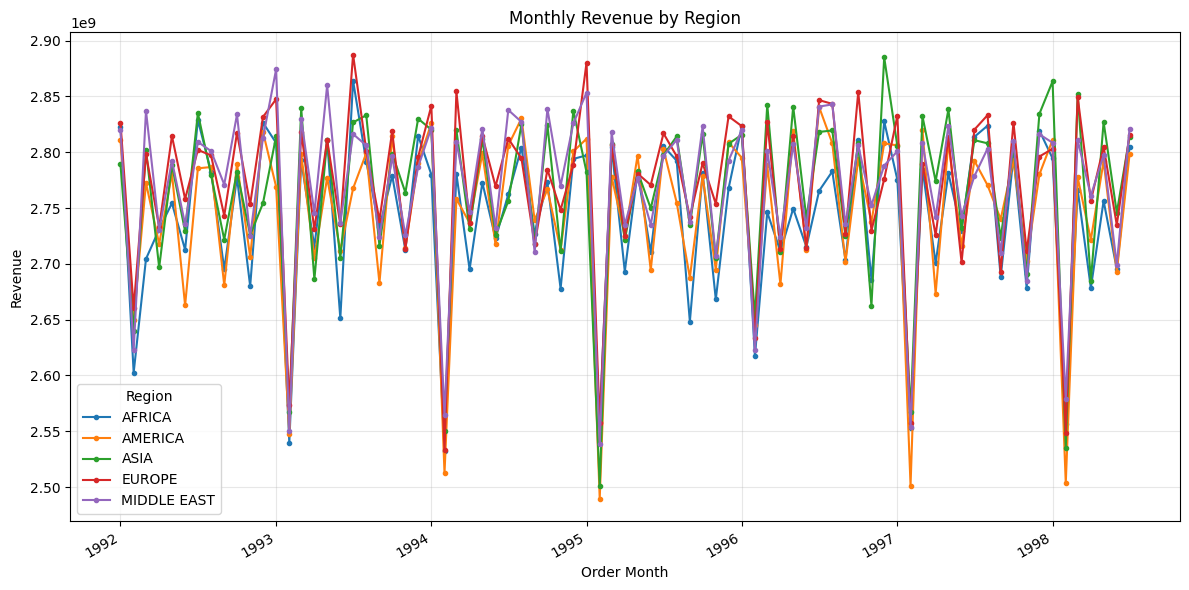

In [0]:
monthly_revenue_df = spark.sql("""
WITH monthly AS (
    SELECT
        CAST(date_trunc('MONTH', f.order_date) AS DATE) AS order_month,
        c.region,
        SUM(f.revenue) AS revenue
    FROM gold.fact_sales f
    JOIN gold.dim_customer c
        ON f.customer_key = c.customer_key
    GROUP BY
        CAST(date_trunc('MONTH', f.order_date) AS DATE),
        c.region
)
SELECT
    order_month,
    region,
    ROUND(revenue, 0) AS revenue
FROM monthly
WHERE order_month < (
    SELECT MAX(order_month)
    FROM monthly
)
ORDER BY order_month, region
""")

import matplotlib.pyplot as plt
import pandas as pd

pdf = monthly_revenue_df.toPandas()
pdf["order_month"] = pd.to_datetime(pdf["order_month"])
pdf = pdf.sort_values("order_month")

fig, ax = plt.subplots(figsize=(12, 6))
for region, grp in pdf.groupby("region"):
    ax.plot(grp["order_month"], grp["revenue"], label=region, marker="o", markersize=3, linewidth=1.5)

ax.set_xlabel("Order Month")
ax.set_ylabel("Revenue")
ax.set_title("Monthly Revenue by Region")
ax.legend(title="Region", loc="best")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 2. Regional revenue rank by quarter

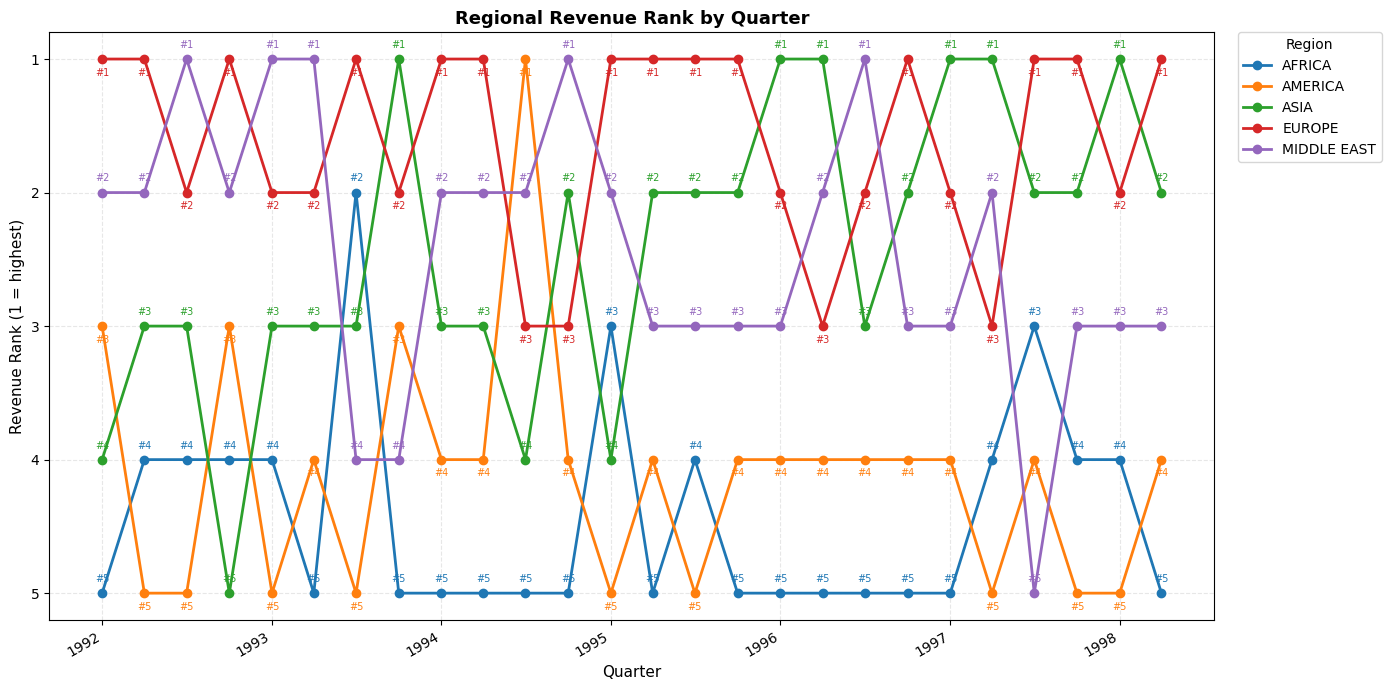

In [0]:
quarterly_rank_df = spark.sql("""
WITH quarterly AS (
    SELECT
        CAST(date_trunc('QUARTER', f.order_date) AS DATE) AS quarter,
        c.region,
        SUM(f.revenue) AS revenue
    FROM gold.fact_sales f
    JOIN gold.dim_customer c
        ON f.customer_key = c.customer_key
    GROUP BY
        CAST(date_trunc('QUARTER', f.order_date) AS DATE),
        c.region
),
complete_quarters AS (
    SELECT *
    FROM quarterly
    WHERE quarter < (
        SELECT MAX(quarter)
        FROM quarterly
    )
)
SELECT
    quarter,
    region,
    ROUND(revenue, 0) AS revenue,
    RANK() OVER (
        PARTITION BY quarter
        ORDER BY revenue DESC
    ) AS revenue_rank
FROM complete_quarters
ORDER BY quarter, revenue_rank
""")

import matplotlib.pyplot as plt
import pandas as pd

pdf = quarterly_rank_df.toPandas()
pdf["quarter"] = pd.to_datetime(pdf["quarter"])

fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.tab10.colors
regions = sorted(pdf["region"].unique())
for i, region in enumerate(regions):
    grp = pdf[pdf["region"] == region].sort_values("quarter")
    ax.plot(
        grp["quarter"],
        grp["revenue_rank"],
        label=region,
        marker="o",
        markersize=6,
        linewidth=2,
        color=colors[i % len(colors)],
    )
    for _, row in grp.iterrows():
        ax.annotate(
            f"#{int(row['revenue_rank'])}",
            (row["quarter"], row["revenue_rank"]),
            textcoords="offset points",
            xytext=(0, 8 if i % 2 == 0 else -12),
            ha="center",
            fontsize=7,
            color=colors[i % len(colors)],
        )

ax.set_xlabel("Quarter", fontsize=11)
ax.set_ylabel("Revenue Rank (1 = highest)", fontsize=11)
ax.set_title("Regional Revenue Rank by Quarter", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.set_yticks(sorted(pdf["revenue_rank"].unique()))
ax.legend(title="Region", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid(True, alpha=0.3, linestyle="--")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 3. Quarter-over-quarter regional performance

This query compares each region with its previous complete quarter.

It combines:

- previous revenue;
- current revenue;
- quarter-over-quarter revenue change;
- previous rank;
- current rank;
- rank change.

For `rank_change`:

- positive value = the region improved its position;
- negative value = the region lost positions.


In [0]:
%sql
WITH quarterly AS (
    SELECT
        CAST(date_trunc('QUARTER', f.order_date) AS DATE) AS quarter,
        c.region,
        SUM(f.revenue) AS revenue
    FROM gold.fact_sales f
    JOIN gold.dim_customer c
        ON f.customer_key = c.customer_key
    GROUP BY
        CAST(date_trunc('QUARTER', f.order_date) AS DATE),
        c.region
),
complete_quarters AS (
    SELECT *
    FROM quarterly
    WHERE quarter < (
        SELECT MAX(quarter)
        FROM quarterly
    )
),
ranked AS (
    SELECT
        quarter,
        region,
        revenue,
        RANK() OVER (
            PARTITION BY quarter
            ORDER BY revenue DESC
        ) AS revenue_rank
    FROM complete_quarters
),
changes AS (
    SELECT
        quarter,
        region,
        revenue,
        revenue_rank,
        LAG(revenue) OVER (
            PARTITION BY region
            ORDER BY quarter
        ) AS previous_revenue,
        LAG(revenue_rank) OVER (
            PARTITION BY region
            ORDER BY quarter
        ) AS previous_rank
    FROM ranked
)
SELECT
    quarter,
    region,
    ROUND(previous_revenue, 0) AS previous_revenue,
    ROUND(revenue, 0) AS revenue,
    ROUND(
        100.0 * (revenue - previous_revenue)
        / NULLIF(previous_revenue, 0),
        2
    ) AS revenue_change_pct,
    previous_rank,
    revenue_rank,
    previous_rank - revenue_rank AS rank_change
FROM changes
WHERE previous_revenue IS NOT NULL
ORDER BY quarter, revenue_rank;


quarter,region,previous_revenue,revenue,revenue_change_pct,previous_rank,revenue_rank,rank_change
1992-04-01,EUROPE,8285127806,8305556390,0.25,1,1,0
1992-04-01,MIDDLE EAST,8279753395,8257988155,-0.26,2,2,0
1992-04-01,ASIA,8231301877,8214693888,-0.20,4,3,1
1992-04-01,AFRICA,8129883421,8198004938,0.84,5,4,1
1992-04-01,AMERICA,8233732057,8161605054,-0.88,3,5,-2
1992-07-01,MIDDLE EAST,8257988155,8381390327,1.49,2,1,1
1992-07-01,EUROPE,8305556390,8342418063,0.44,1,2,-1
1992-07-01,ASIA,8214693888,8336617406,1.48,3,3,0
1992-07-01,AFRICA,8198004938,8306736720,1.33,4,4,0
1992-07-01,AMERICA,8161605054,8253219185,1.12,5,5,0
